# Static Move Prediction Draft

## Setup Environment && Load Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dataclasses import dataclass

import mlflow
import optuna

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from chesswinnerprediction.static_move.models.static_move_base import StaticMoveBaseModel

from config import RANDOM_STATE
from chesswinnerprediction.static_move.utils import load_train_valid_test, setup_mlflow

## Setup MLflow

In [3]:
setup_mlflow(experiment_name="Static Move Prediction")

## Load Data

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test()

In [5]:
X_test.shape

(30000, 14)

## Optuna

In [6]:
def get_model(trial: optuna.Trial, model_type):
    if model_type == RandomForestClassifier.__name__:
        model = RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
            n_estimators=trial.suggest_int("forest_n_estimators", 10, 250),
            max_depth=trial.suggest_int("forest_max_depth", 6, 20),
            min_samples_leaf=trial.suggest_int("forest_min_samples_leaf", 1, X_train.shape[0]//4),
            max_features="sqrt",
            ccp_alpha=trial.suggest_float("forest_ccp_alpha", 0.0, 0.1),
        )
    elif model_type == GradientBoostingClassifier.__name__:
        model = GradientBoostingClassifier(
            n_iter_no_change=5,
            tol=1e-3,
            random_state=RANDOM_STATE,
            learning_rate=trial.suggest_float("boosting_learning_rate", 1e-3, 1e-1, log=True),
            n_estimators=trial.suggest_int("boosting_n_estimators", 2, 150),
            max_depth=trial.suggest_int("boosting_max_depth", 2, 16),
            min_samples_leaf=trial.suggest_int(f"boosting_min_samples_leaf", 1, X_train.shape[0]//4),
            max_features="sqrt",
        )
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return model

In [7]:
@dataclass
class BestModel:
    trial: optuna.Trial = None
    score: float = 0.0
    run_id: str = ""
    model: StaticMoveBaseModel = None

In [25]:
class Objective:
    def __init__(self, parent_run_id, model_types):
        self.parent_run_id = parent_run_id
        self.model_types = model_types
        self._best_models = self.__generate_best_model_dict()
        
    def __call__(self, trial: optuna.Trial):
        model_type = trial.suggest_categorical("model_type", self.model_types)

        estimator = get_model(trial, model_type)
        model = StaticMoveBaseModel(estimator=estimator)
        model.fit(X_train, y_train)

        model.score(X_valid, y_valid)
        self.log_trial(trial, model)
        
        return model.balanced_accuracy
    
    def log_trial(self, trial, model: StaticMoveBaseModel):
        score = model.balanced_accuracy
        model_type = trial.params["model_type"]
        if score > self._best_models[model_type].score:
            self._best_models[model_type].model = model
            self._best_models[model_type].score = score
            self._best_models[model_type].trial = trial
        
        
        run_id = self._best_models[model_type].run_id
        with mlflow.start_run(nested=True, run_id=run_id, parent_run_id=self.parent_run_id) as model_run:
            with mlflow.start_run(nested=True, run_name=f"Trial_{trial.number}", parent_run_id=model_run.info.run_id):
                # mlflow.log_params(trial.params)
                model.log_trial()
        
    def log_best(self, trial):
        best_mode = self._best_models[trial.params["model_type"]]
        mlflow.log_params(best_mode.trial.params)
        best_mode.model.log_trial()
        
        for model_type in self.model_types:
            best_model_data = self._best_models[model_type]
            if best_model_data.model is None:
                mlflow.delete_run(best_model_data.run_id)
                continue
            with mlflow.start_run(nested=True, run_id=best_model_data.run_id, parent_run_id=self.parent_run_id) as model_run:
                mlflow.log_params(best_model_data.trial.params)
                best_model_data.model.log_trial()
        
    def __generate_best_model_dict(self):
        best_models = {}
        for model_type in self.model_types:
            with mlflow.start_run(nested=True, run_name=model_type, parent_run_id=self.parent_run_id) as model_run:
                best_models[model_type] = BestModel(run_id=model_run.info.run_id)
        return best_models

In [26]:
study = optuna.create_study(direction="maximize", study_name="Static Move Prediction")

# models_types = [RandomForestClassifier.__name__, GradientBoostingClassifier.__name__]
models_types = [GradientBoostingClassifier.__name__]

[I 2024-08-17 18:32:51,490] A new study created in memory with name: Static Move Prediction


In [27]:
with mlflow.start_run(run_name="Optuna") as main_run:
    objective = Objective(parent_run_id=main_run.info.run_id, model_types=models_types)
    study.optimize(objective, n_trials=3, show_progress_bar=True)
    objective.log_best(study.best_trial)

  0%|          | 0/3 [00:00<?, ?it/s]

[I 2024-08-17 18:33:10,304] Trial 0 finished with value: 0.5701 and parameters: {'model_type': 'GradientBoostingClassifier', 'boosting_learning_rate': 0.012061977211325842, 'boosting_n_estimators': 126, 'boosting_max_depth': 7, 'boosting_min_samples_leaf': 12917}. Best is trial 0 with value: 0.5701.
[I 2024-08-17 18:33:27,115] Trial 1 finished with value: 0.5679 and parameters: {'model_type': 'GradientBoostingClassifier', 'boosting_learning_rate': 0.0016614420962958747, 'boosting_n_estimators': 91, 'boosting_max_depth': 8, 'boosting_min_samples_leaf': 4947}. Best is trial 0 with value: 0.5701.
[I 2024-08-17 18:33:33,510] Trial 2 finished with value: 0.5785333333333333 and parameters: {'model_type': 'GradientBoostingClassifier', 'boosting_learning_rate': 0.05265306602196806, 'boosting_n_estimators': 43, 'boosting_max_depth': 12, 'boosting_min_samples_leaf': 9764}. Best is trial 2 with value: 0.5785333333333333.


In [28]:
from sklearn.metrics import classification_report

In [29]:
best_model = get_model(study.best_trial, study.best_trial.params["model_type"])

In [30]:
best_model.verbose = 3
# best_model.tol = 1e-2
# best_model.n_iter_no_change = 5

In [31]:
best_model.fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.0859            5.49s
         2           1.0746            5.76s
         3           1.0672            5.62s
         4           1.0595            5.39s
         5           1.0518            5.39s
         6           1.0463            5.14s
         7           1.0389            4.93s
         8           1.0319            4.81s
         9           1.0260            4.68s
        10           1.0182            4.49s
        11           1.0127            4.37s
        12           1.0082            4.22s
        13           1.0014            4.09s
        14           0.9960            3.99s
        15           0.9885            3.85s
        16           0.9858            3.69s
        17           0.9817            3.53s
        18           0.9776            3.42s
        19           0.9741            3.27s
        20           0.9700            3.17s
        21           0.9670            3.02s
        2

GradientBoostingClassifier(learning_rate=0.05265306602196806, max_depth=12,
                           max_features='sqrt', min_samples_leaf=9764,
                           n_estimators=43, n_iter_no_change=5, random_state=42,
                           tol=0.001, verbose=3)

In [32]:
y_pred = best_model.predict(X_test)

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0-1       0.59      0.58      0.58     10000
         1-0       0.56      0.62      0.59     10000
     1/2-1/2       0.63      0.59      0.61     10000

    accuracy                           0.59     30000
   macro avg       0.60      0.59      0.60     30000
weighted avg       0.60      0.59      0.60     30000



In [34]:
# show feature importance

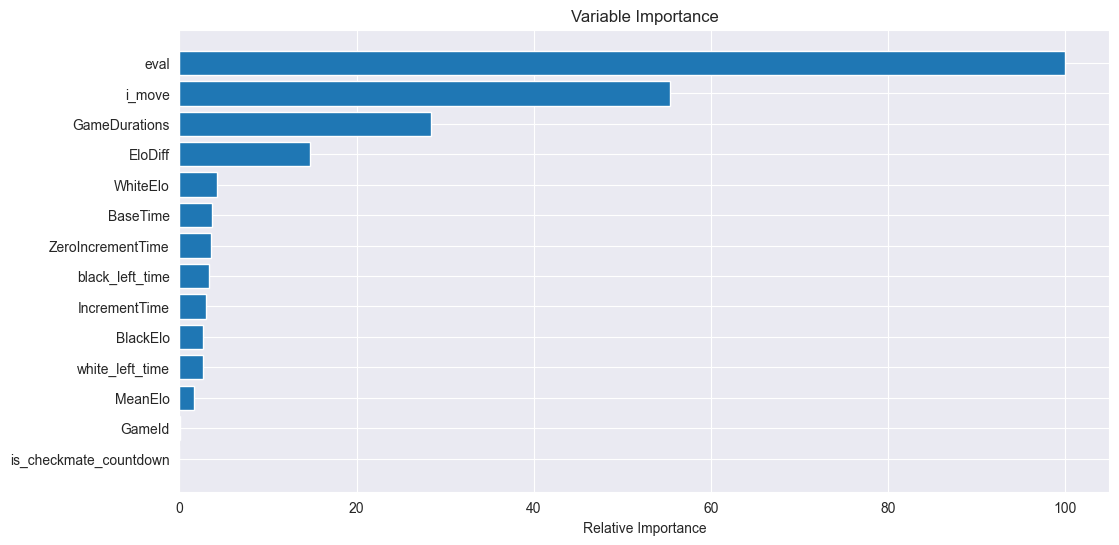

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

feature_importance = best_model.feature_importances_
feature_importance = 100.0 * (feature_importance / feature_importance.max())
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(12, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, X_train.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance')
plt.show()

In [47]:
X, Y = X_test, y_test

In [64]:
Y[X["i_move"] < 50].value_counts()

Result
1-0        6020
0-1        5980
1/2-1/2    2774
Name: count, dtype: int64

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, balanced_accuracy_score

In [55]:
def bin_i_moves(i_moves, n_bins=24):
    """Bins i_move values into specified number of bins."""
    max_i_move = max(i_moves)
    bin_edges = np.linspace(0, max_i_move, n_bins + 1)
    bins = pd.cut(i_moves, bins=bin_edges, labels=False, include_lowest=True)
    return bins

In [56]:
# Initialize dictionaries to store metrics
balanced_accuracy_per_bin = {}
recall_per_bin = {class_label: {} for class_label in ["1-0", "0-1", "1/2-1/2"]}
precision_per_bin = {class_label: {} for class_label in ["1-0", "0-1", "1/2-1/2"]}

# Bin the i_move values
i_move_bins = bin_i_moves(X["i_move"], n_bins=24)

In [57]:
# Iterate over each bin
for bin_id in range(24):
    # Filter data for the current bin
    bin_mask = (i_move_bins == bin_id)
    X_test_filtered = X[bin_mask]
    y_test_filtered = Y[X_test_filtered.index]
    
    if len(y_test_filtered) == 0:
        continue  # Skip empty bins
    
    # Predict using the best model
    y_pred = best_model.predict(X_test_filtered)
    
    # Calculate balanced accuracy for the bin
    balanced_acc = balanced_accuracy_score(y_test_filtered, y_pred)
    balanced_accuracy_per_bin[bin_id] = balanced_acc
    
    # Calculate recall and precision for each class
    for class_label in recall_per_bin.keys():
        recall = recall_score(y_test_filtered, y_pred, labels=[class_label], average='macro')
        recall_per_bin[class_label][bin_id] = recall

        precision = precision_score(y_test_filtered, y_pred, labels=[class_label], average='macro')
        precision_per_bin[class_label][bin_id] = precision

In [58]:
# Convert bin_id to edges for plotting
bin_edges = np.linspace(0, max(X["i_move"]), 25)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

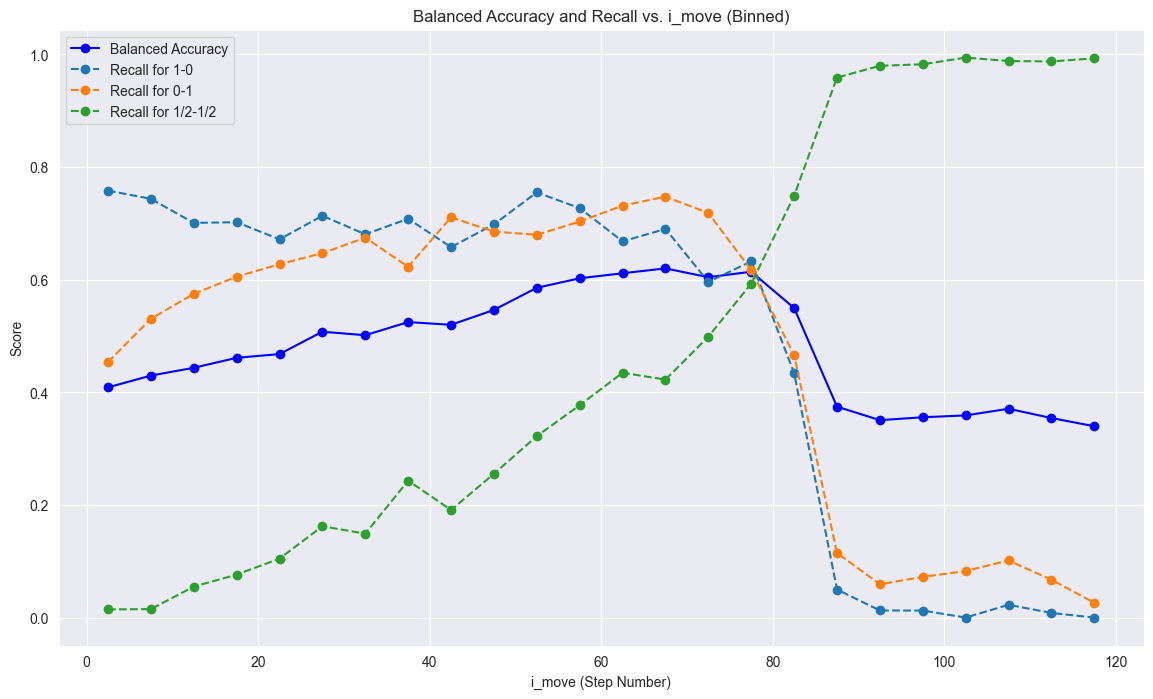

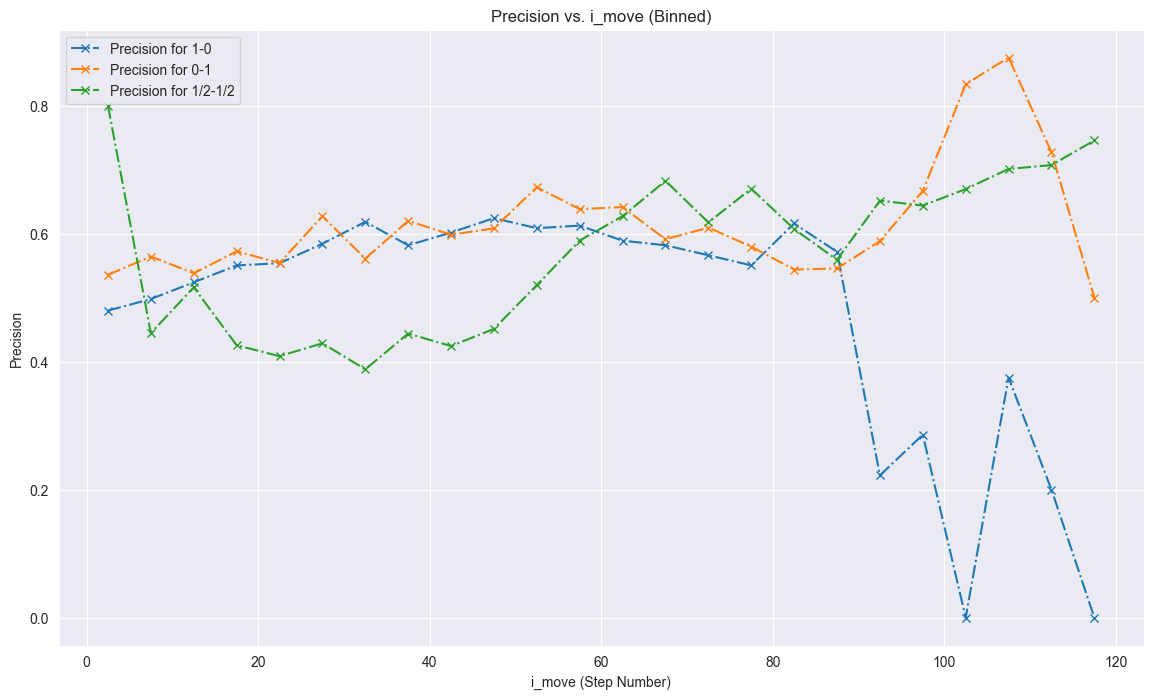

In [59]:
# Plot balanced accuracy and recall
plt.figure(figsize=(14, 8))

# Plot balanced accuracy
plt.plot(bin_centers, [balanced_accuracy_per_bin.get(i, 0) for i in range(24)], marker='o', linestyle='-', color='b', label='Balanced Accuracy')

# Plot recall
for class_label in recall_per_bin.keys():
    sorted_recalls = [recall_per_bin[class_label].get(i, 0) for i in range(24)]
    plt.plot(bin_centers, sorted_recalls, marker='o', linestyle='--', label=f'Recall for {class_label}')

# Add labels and title
plt.xlabel('i_move (Step Number)')
plt.ylabel('Score')
plt.title('Balanced Accuracy and Recall vs. i_move (Binned)')
plt.legend()
plt.grid(True)
plt.show()

# Plot precision on a separate plot
plt.figure(figsize=(14, 8))

# Plot precision
for class_label in precision_per_bin.keys():
    sorted_precisions = [precision_per_bin[class_label].get(i, 0) for i in range(24)]
    plt.plot(bin_centers, sorted_precisions, marker='x', linestyle='-.', label=f'Precision for {class_label}')

# Add labels and title
plt.xlabel('i_move (Step Number)')
plt.ylabel('Precision')
plt.title('Precision vs. i_move (Binned)')
plt.legend()
plt.grid(True)
plt.show()

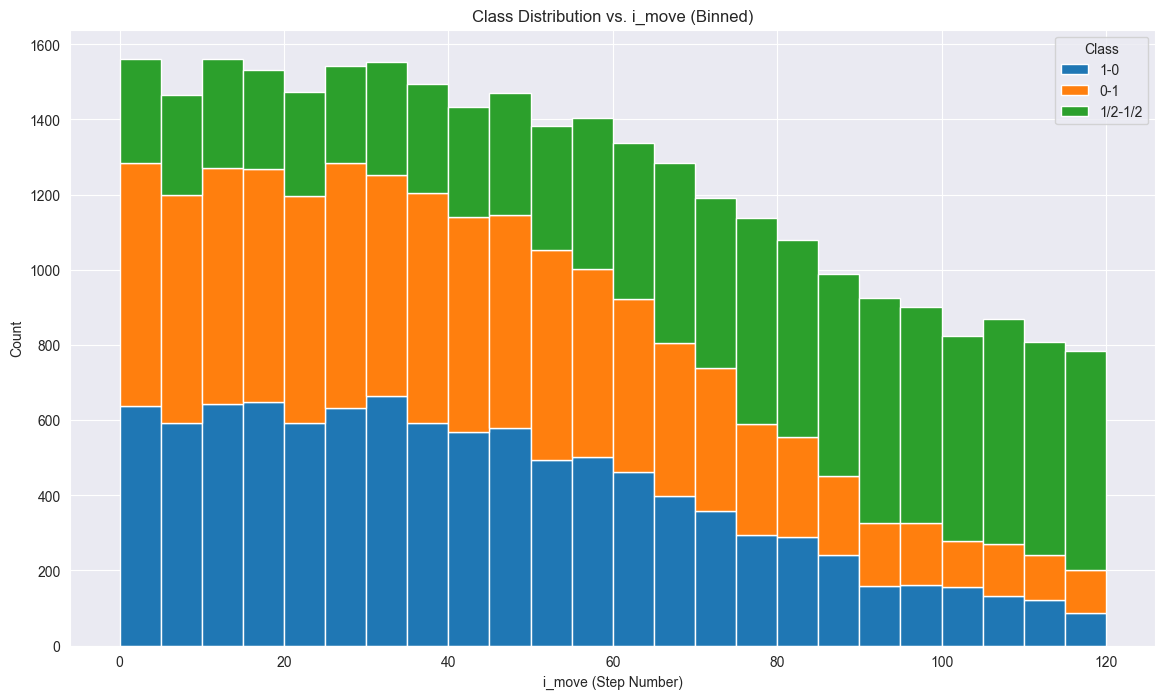

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bin the i_move values (reusing the binning function from before)
i_move_bins = bin_i_moves(X["i_move"], n_bins=24)

# Initialize a DataFrame to store class counts for each bin
class_distribution_per_bin = pd.DataFrame(0, index=range(24), columns=["1-0", "0-1", "1/2-1/2"])

# Iterate over each bin and count the class occurrences
for bin_id in range(24):
    bin_mask = (i_move_bins == bin_id)
    y_test_filtered = Y[bin_mask]
    
    # Count the occurrences of each class in the current bin
    class_counts = y_test_filtered.value_counts()
    
    # Update the DataFrame with the counts
    for class_label in class_counts.index:
        class_distribution_per_bin.loc[bin_id, class_label] = class_counts[class_label]

# Convert bin_id to edges for plotting
bin_edges = np.linspace(0, max(X["i_move"]), 25)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create a stacked bar plot
plt.figure(figsize=(14, 8))
bar_width = bin_centers[1] - bin_centers[0]

# Plot the bars
bottom_values = np.zeros(24)
for class_label in class_distribution_per_bin.columns:
    plt.bar(bin_centers, class_distribution_per_bin[class_label], width=bar_width, bottom=bottom_values, label=class_label)
    bottom_values += class_distribution_per_bin[class_label]

# Add labels and title
plt.xlabel('i_move (Step Number)')
plt.ylabel('Count')
plt.title('Class Distribution vs. i_move (Binned)')
plt.legend(title="Class")
plt.grid(True)
plt.show()
